## Using PCA to classify midfielder roles


In [1]:
# Import necessary libraries
import math

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from PIL import Image
from matplotlib.colors import LinearSegmentedColormap
from mplsoccer import PyPizza, add_image
from sklearn import decomposition, preprocessing
from sklearn.cluster import KMeans

In [2]:
# Import the data
shooting = pd.read_csv("Data/Shooting.csv", encoding="utf-8", sep=",").fillna(0)
passing = pd.read_csv("Data/Passing.csv", encoding="utf-8", sep=",").fillna(0)
passType = pd.read_csv("Data/PassTypes.csv", encoding="utf-8", sep=",").fillna(0)
possession = pd.read_csv("Data/Possession.csv", encoding="utf-8", sep=",").fillna(0)
defending = pd.read_csv("Data/Defensive.csv", encoding="utf-8", sep=",").fillna(0)
misc = pd.read_csv("Data/Misc.csv", encoding="utf-8", sep=",").fillna(0)

teamPossession = pd.read_csv("Data/TeamPossession.csv", encoding="utf-8", sep=",")

In [3]:
# Dataframe for possession-adjusted defensive stats
defending_adj = defending.copy().drop(columns=["Player"])

# Map the team names to the team names in the possession dataframe
defending_adj["Possession"] = defending_adj["Squad"].map(
    teamPossession.set_index("Squad")["Poss"]
)

# Calculate opposition's possession time
## Take 60 minutes as the ball in play time
defending_adj["OppPossession"] = 60 * (100 - defending_adj["Possession"]) / 100

# Calculate possession-adjusted stats
## Use 30 as the normalization factor
calculated_cols = defending_adj.columns[1:-2]
for col in calculated_cols:
    defending_adj["PAdj " + col] = round(
        30 * defending_adj[col] / defending_adj["OppPossession"], 2
    )

# Drop the original columns
defending_adj = defending_adj.drop(
    columns=calculated_cols.to_list() + ["Possession", "OppPossession"]
)

# Add the player column back to the start
defending_adj = defending[["Player"]].join(defending_adj)

In [5]:
defending_adj.sort_values(
    by=["PAdj Tackles Attempted", "PAdj Interceptions"], ascending=False
)

,Player,Squad,PAdj Tackles Attempted,PAdj Tackles in Def 3rd,PAdj Tackles in Mid 3rd,PAdj Tackles in Att 3rd,PAdj Challenges Attempted,PAdj Blocked Passes,PAdj Interceptions,PAdj Clearances
45,Alicia Woods,Brisbane,5.70,1.64,3.55,0.51,3.80,1.14,2.03,0.75
17,Isabel Gomez,Central Coast Mariners,5.21,3.13,1.56,0.52,4.69,2.60,2.09,1.56
30,Maya McCutcheon,Wellington Phoenix FC,4.71,2.69,1.68,0.33,2.13,1.01,1.45,4.48
18,Ena Harada,W Sydney,4.27,2.47,1.35,0.45,2.81,1.01,2.36,1.91
20,Momo Hayashi,Brisbane,3.89,0.90,2.71,0.26,2.71,0.90,2.59,1.42
21,Sophie Hoban,Newcastle,3.76,0.65,2.34,0.78,1.82,1.17,0.78,0.52
47,Talia Younis,W Sydney,3.64,1.82,0.61,1.22,2.19,0.73,0.49,0.97
4,Amy Chessari,W Sydney,3.63,1.75,1.32,0.55,2.53,0.65,2.53,1.43
11,Cassidy Davis,Newcastle,3.43,1.10,1.59,0.74,1.96,0.62,0.62,1.84
34,Sarah O'Donoghue,Perth,3.11,0.52,1.29,1.29,2.33,0.26,0.52,1.29


In [6]:
# Merge all the dataframes
df = shooting.merge(passing, on=["Player", "Squad"], how="inner")
df = df.merge(passType, on=["Player", "Squad"], how="inner")
df = df.merge(possession, on=["Player", "Squad"], how="inner")
df = df.merge(defending_adj, on=["Player", "Squad"], how="inner")
df = df.merge(misc, on=["Player", "Squad"], how="inner")

# Normalize and z-score the data
df_metrics = df.drop(columns=["Player", "Squad"])
scaler = preprocessing.MinMaxScaler()
normalised = scaler.fit_transform(df_metrics)

# Perform PCA
pca = decomposition.PCA(n_components=len(df_metrics.columns))
pca.fit(normalised)

# Transform the data
pca_scores = pca.transform(normalised)

# Get the loadings
loadings = pd.DataFrame(
    pca.components_.T, columns=[f"PC{i + 1}" for i in range(pca.n_components)]
)

# Assign the loadings to the respective metrics
loadings.index = df_metrics.columns

In [7]:
# Get the top 10 loadings for each PC
top5_loadings = pd.DataFrame(
    {
        f"PC{i + 1}": loadings[f"PC{i + 1}"].nlargest(5).index
        for i in range(pca.n_components)
    }
)
top5_loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29
0,Touches in Def 3rd,Passes Received,PAdj Tackles in Att 3rd,Crosses,PAdj Interceptions,Shots,Through balls,PAdj Tackles in Att 3rd,Progressive Passes,PAdj Blocked Passes,...,Progressive Passes Received,Long Passes Attempted,Progressive Passes Received,Touches in Def 3rd,Touches in Att 3rd,Passes Received,Touches in Mid 3rd,Live-ball Passes,Passes Attempted,PAdj Tackles Attempted
1,PAdj Interceptions,Passes into Penalty box,PAdj Tackles Attempted,Long Passes Attempted,Through balls,PAdj Tackles in Att 3rd,PAdj Clearances,PAdj Interceptions,Passes into Penalty box,Ball recoveries,...,Progressive Passes,Passes Received,Medium Passes Attempted,Passes into Final Third,Carries,Live-ball Passes,Passes Received,Touches in Mid 3rd,Progressive Passes Received,Short Passes Attempted
2,Touches in Mid 3rd,Touches in Att 3rd,PAdj Challenges Attempted,PAdj Tackles in Def 3rd,Progressive Passes,Through balls,Progressive Carries,Progressive Carries,PAdj Tackles in Def 3rd,PAdj Tackles in Att 3rd,...,Crosses,Touches in Def 3rd,Passes into Final Third,Passes into Penalty box,PAdj Challenges Attempted,Ball recoveries,Touches in Att 3rd,Key Passes,Key Passes,Medium Passes Attempted
3,Medium Passes Attempted,Carries,PAdj Tackles in Def 3rd,Key Passes,Passes into Final Third,Passes Received,PAdj Tackles in Att 3rd,Short Passes Attempted,PAdj Tackles Attempted,Long Passes Attempted,...,PAdj Tackles in Mid 3rd,Progressive Carries,Long Passes Attempted,Carries,Through balls,Attempted Take-ons,Touches in Def 3rd,Progressive Passes,Attempted Take-ons,Long Passes Attempted
4,Live-ball Passes,Passes Attempted,PAdj Tackles in Mid 3rd,PAdj Interceptions,PAdj Tackles in Mid 3rd,PAdj Tackles Attempted,Ball recoveries,Crosses,PAdj Clearances,Progressive Passes,...,Touches in Def 3rd,Short Passes Attempted,PAdj Tackles Attempted,Shots,PAdj Clearances,Medium Passes Attempted,Passes into Final Third,Touches in Att 3rd,PAdj Tackles Attempted,Passes Received


In [8]:
df.columns.to_list()

['Player',
 'Squad',
 'Shots',
 'Passes Attempted',
 'Short Passes Attempted',
 'Medium Passes Attempted',
 'Long Passes Attempted',
 'Key Passes',
 'Passes into Final Third',
 'Passes into Penalty box',
 'Progressive Passes',
 'Live-ball Passes',
 'Through balls',
 'Crosses',
 'Touches in Def 3rd',
 'Touches in Mid 3rd',
 'Touches in Att 3rd',
 'Attempted Take-ons',
 'Carries',
 'Progressive Carries',
 'Passes Received',
 'Progressive Passes Received',
 'PAdj Tackles Attempted',
 'PAdj Tackles in Def 3rd',
 'PAdj Tackles in Mid 3rd',
 'PAdj Tackles in Att 3rd',
 'PAdj Challenges Attempted',
 'PAdj Blocked Passes',
 'PAdj Interceptions',
 'PAdj Clearances',
 'Ball recoveries']

In [9]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_pcs = (
    np.argmax(cumulative_variance >= 0.8) + 1
)  # Retain enough PCs to explain 80% variance

([<matplotlib.axis.XTick at 0x255cd294080>,
 [Text(0.5, 0, 'Progressor'),
  Text(1.5, 0, 'Engine'),
  Text(2.5, 0, 'Ball-winner'),
  Text(3.5, 0, 'Reader'),
  Text(4.5, 0, 'Playmaker'),
  Text(5.5, 0, 'Second striker'),
  Text(6.5, 0, 'Ball carrier')])

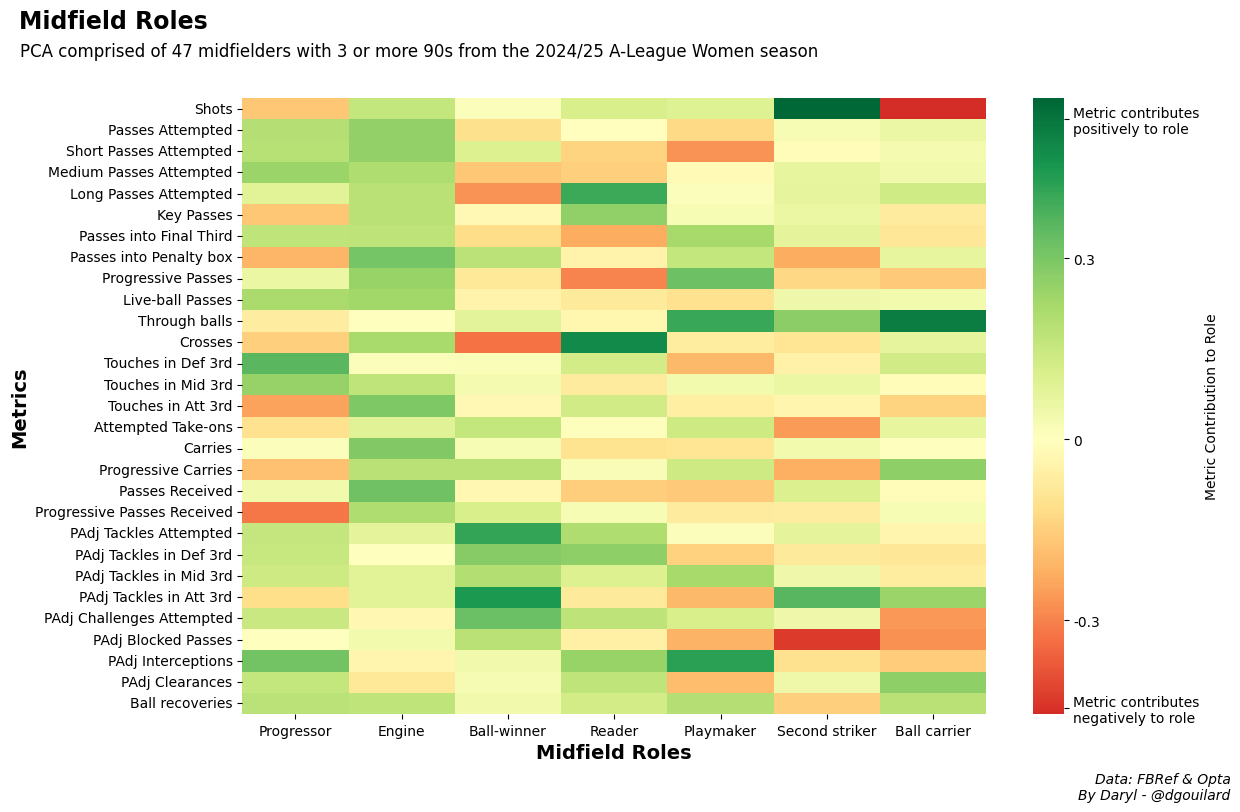

In [10]:
# Visualize the loadings (heatmap for interpretation)
plt.figure(figsize=(12, 8))
heatmap = sns.heatmap(
    loadings.iloc[:, :n_pcs],
    cmap="RdYlGn",
    center=0,
    cbar_kws={
        "label": "Metric Contribution to Role",
        "ticks": [
            loadings.min().min() + 0.05,
            -0.3,
            0,
            0.3,
            loadings.max().max() - 0.35,
        ],
    },
)
cbar = heatmap.collections[0].colorbar
cbar.set_ticklabels(
    [
        "Metric contributes\nnegatively to role",
        "-0.3",
        "0",
        "0.3",
        "Metric contributes\npositively to role",
    ]
)
plt.title("Midfield Roles", fontsize=17, fontweight="bold", ha="left", y=1.1, x=-0.3)
plt.suptitle(
    "PCA comprised of 47 midfielders with 3 or more 90s from the 2024/25 A-League Women season",
    ha="left",
    y=0.95,
    x=-0.06,
)
plt.xlabel("Midfield Roles", fontsize=14, fontweight="bold")
plt.ylabel("Metrics", fontsize=14, fontweight="bold")
plt.text(
    9.3,
    33,
    "Data: FBRef & Opta\nBy Daryl - @dgouilard",
    weight="light",
    style="italic",
    fontsize=10,
    ha="right",
)

# Set x-axis to display the roles
plt.xticks(
    ticks=np.arange(n_pcs) + 0.5,
    labels=[
        "Progressor",
        "Engine",
        "Ball-winner",
        "Reader",
        "Playmaker",
        "Second striker",
        "Ball carrier",
    ],
    rotation=0,
)

([<matplotlib.axis.XTick at 0x255d13cf9e0>,
 [Text(0.5, 0, 'Progressor'),
  Text(1.5, 0, 'Engine'),
  Text(2.5, 0, 'Ball-winner'),
  Text(3.5, 0, 'Reader'),
  Text(4.5, 0, 'Creator'),
  Text(5.5, 0, 'Second striker'),
  Text(6.5, 0, 'Ball carrier')])

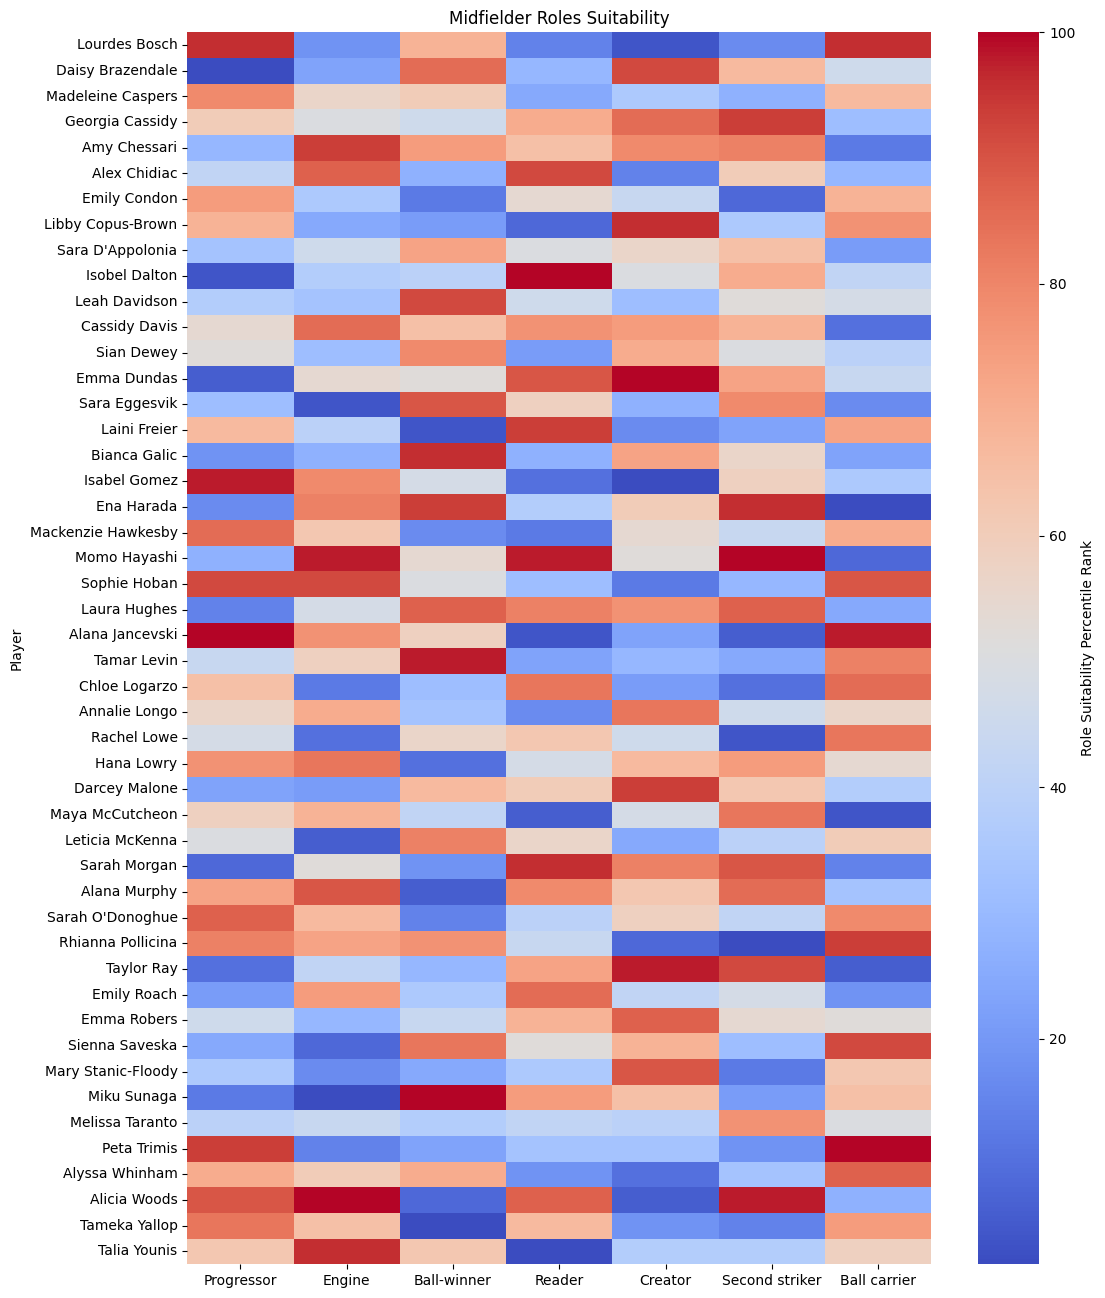

In [11]:
# Calculate percentile rank for each role (based on PCA loadings)
# Define a function to calculate percentile rank for a player fitting into a role
def calculate_role_percentile(player_scores, role_loadings):
    role_fit_score = np.dot(player_scores, role_loadings)
    return role_fit_score


# Create a DataFrame to store percentile ranks for each player-role combination
roles = [f"Role {i+1}" for i in range(n_pcs)]
role_percentiles = pd.DataFrame(index=df["Player"], columns=roles)

for i in range(n_pcs):
    role_loadings = loadings[f"PC{i+1}"].values
    role_percentiles[roles[i]] = calculate_role_percentile(pca_scores, role_loadings)

# Normalize the percentiles to a 0-100 scale
role_percentiles = role_percentiles.rank(pct=True).multiply(100)

# Visualize the roles and player fit
plt.figure(figsize=(12, 16))
sns.heatmap(
    role_percentiles,
    cmap="coolwarm",
    annot=False,
    cbar_kws={"label": "Role Suitability Percentile Rank"},
)
plt.title("Midfielder Roles Suitability")

# Set x-axis to display the roles
plt.xticks(
    ticks=np.arange(n_pcs) + 0.5,
    labels=[
        "Progressor",
        "Engine",
        "Ball-winner",
        "Reader",
        "Creator",
        "Second striker",
        "Ball carrier",
    ],
    rotation=0,
)

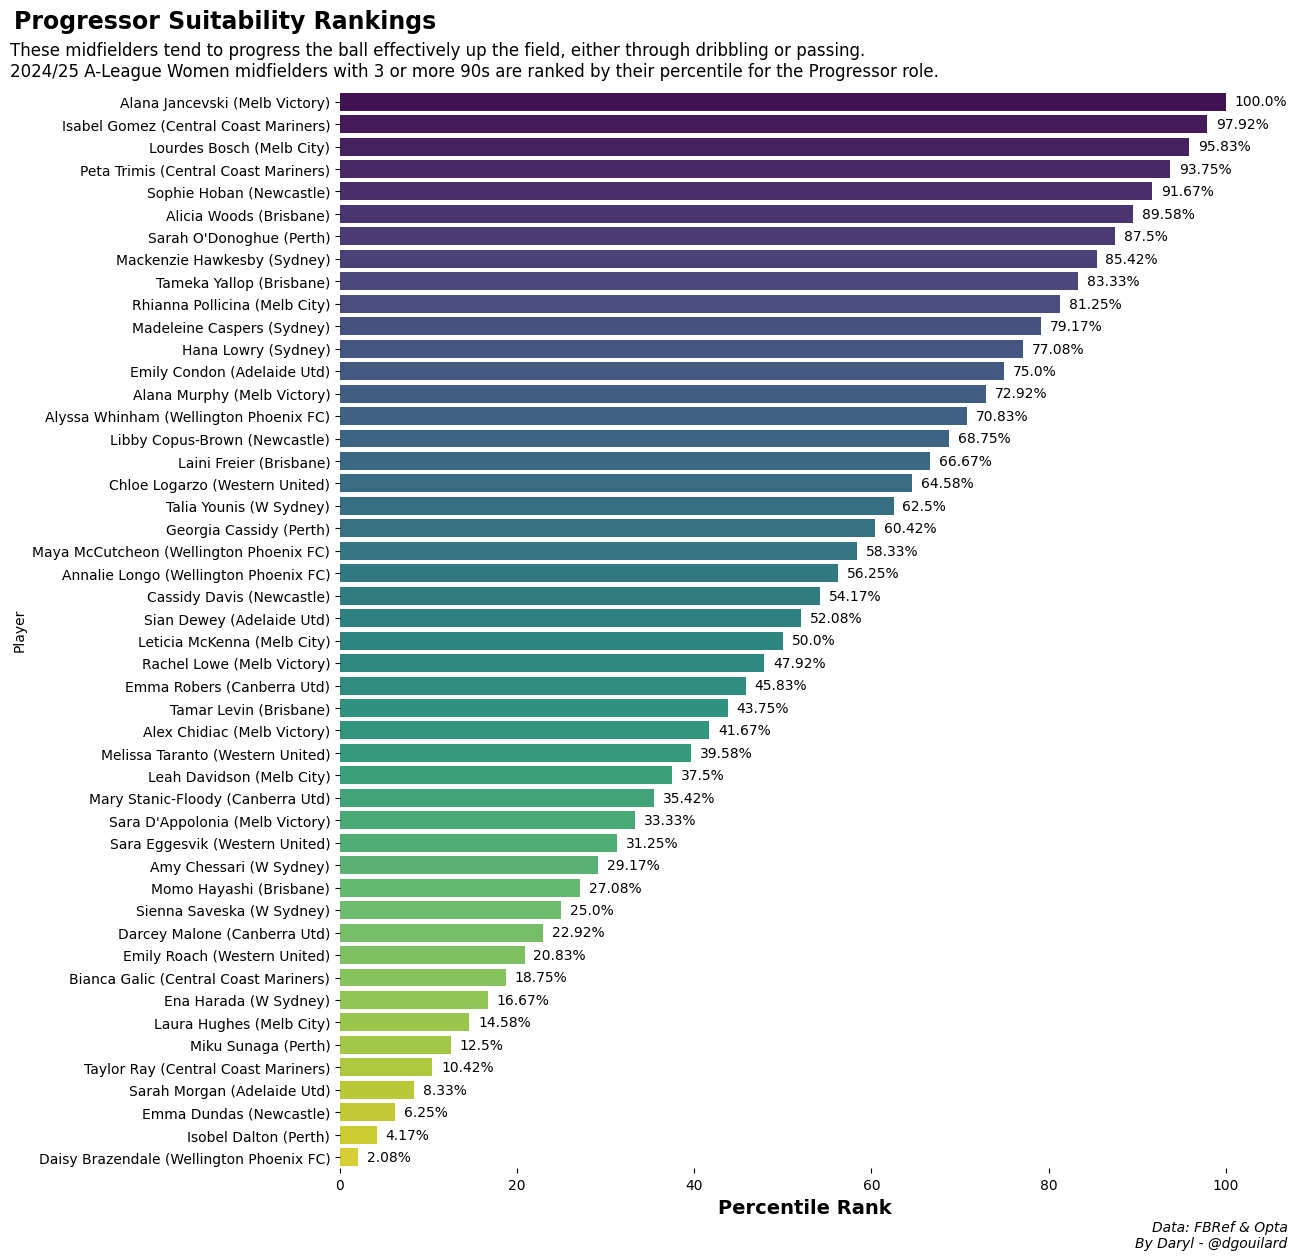

In [12]:
# Sort the roles
role_1 = role_percentiles["Role 1"].sort_values(ascending=False)

# Add team name to the player name
role_1 = role_1.reset_index()
role_1["Player"] = role_1["Player"].apply(
    lambda x: x + " (" + df[df["Player"] == x]["Squad"].values[0] + ")"
)
role_1 = role_1.set_index("Player")
role_1 = role_1["Role 1"]

# Visualize the rankings for Role 1
plt.figure(figsize=(12, 14))
sns.barplot(x=role_1.values, y=role_1.index, palette="viridis", hue=role_1.index)

# Add the percentile values to the bars
for i in range(role_1.shape[0]):
    plt.text(
        x=role_1.values[i] + 1,
        y=i,
        s=f"{round(role_1.values[i], 2)}%",
        va="center",
        ha="left",
    )

# Set the title and labels
plt.title(
    "Progressor Suitability Rankings",
    fontsize=17,
    fontweight="bold",
    ha="left",
    y=1.05,
    x=-0.35,
)
plt.suptitle(
    "These midfielders tend to progress the ball effectively up the field, either through dribbling or passing.\n2024/25 A-League Women midfielders with 3 or more 90s are ranked by their percentile for the Progressor role.",
    ha="left",
    y=0.915,
    x=-0.15,
)
plt.xlabel("Percentile Rank", fontsize=14, fontweight="bold")
plt.text(
    107,
    51,
    "Data: FBRef & Opta\nBy Daryl - @dgouilard",
    weight="light",
    style="italic",
    fontsize=10,
    ha="right",
)

# Remove the frame
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)

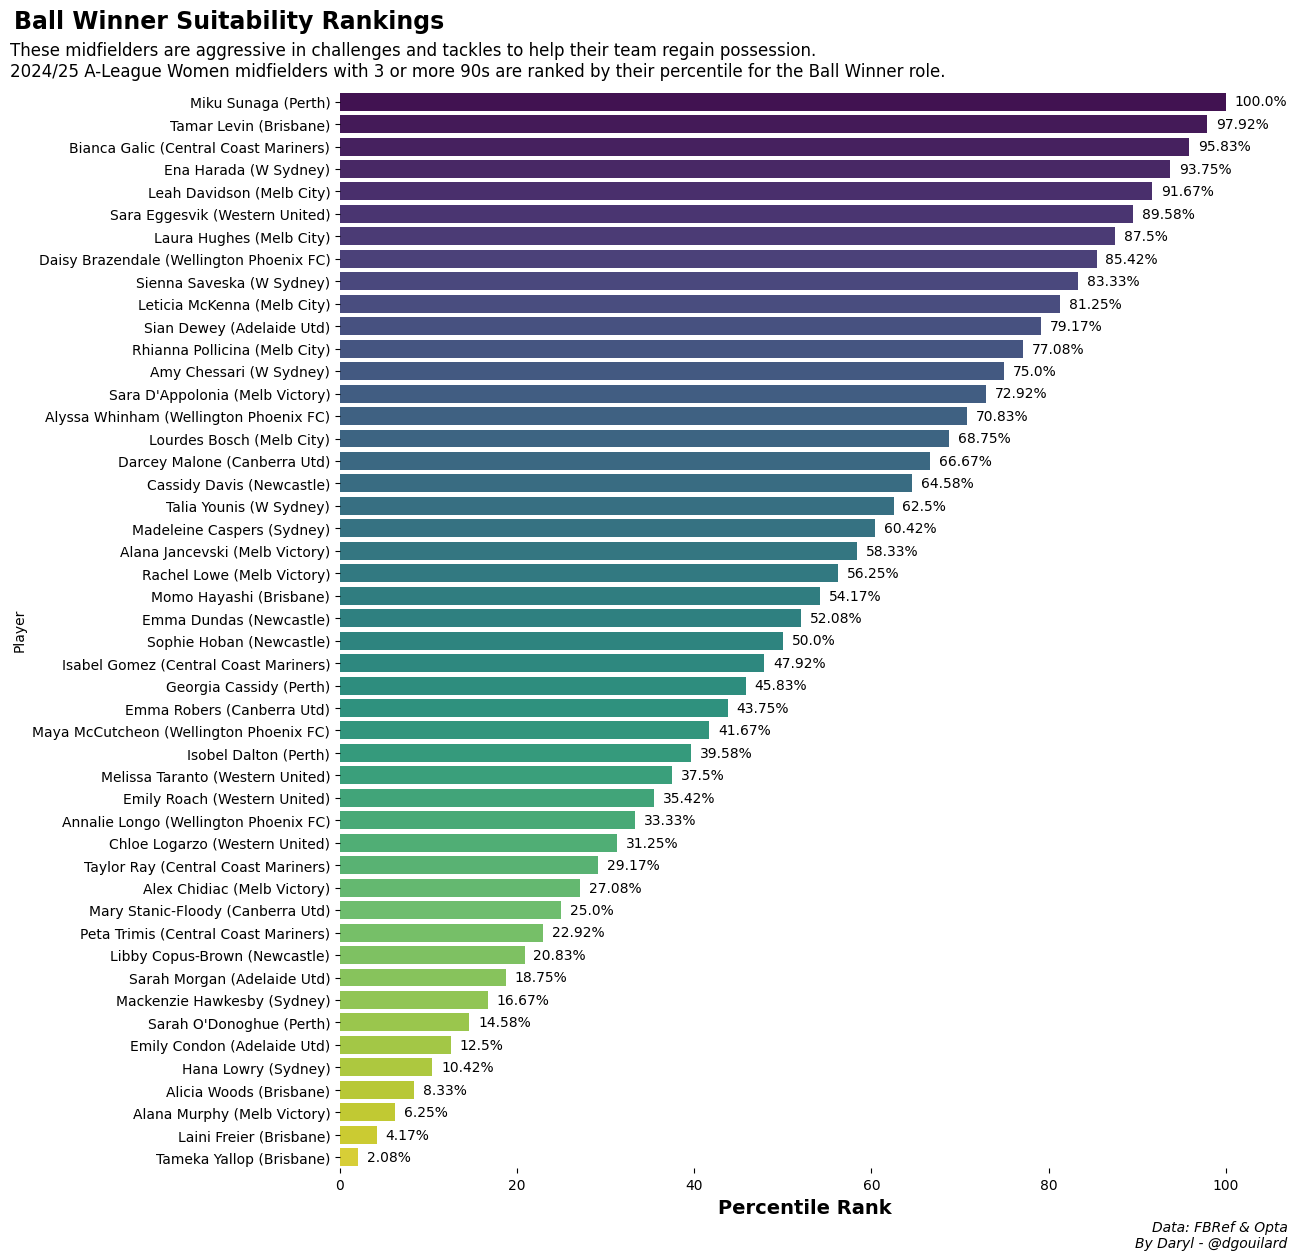

In [13]:
# Sort the roles
role_3 = role_percentiles["Role 3"].sort_values(ascending=False)

# Add team name to the player name
role_3 = role_3.reset_index()
role_3["Player"] = role_3["Player"].apply(
    lambda x: x + " (" + df[df["Player"] == x]["Squad"].values[0] + ")"
)
role_3 = role_3.set_index("Player")
role_3 = role_3["Role 3"]

# Visualize the rankings for Role 3
plt.figure(figsize=(12, 14))
sns.barplot(x=role_3.values, y=role_3.index, palette="viridis", hue=role_3.index)

# Add the percentile values to the bars
for i in range(role_3.shape[0]):
    plt.text(
        x=role_3.values[i] + 1,
        y=i,
        s=f"{round(role_3.values[i], 2)}%",
        va="center",
        ha="left",
    )

# Set the title and labels
plt.title(
    "Ball Winner Suitability Rankings",
    fontsize=17,
    fontweight="bold",
    ha="left",
    y=1.05,
    x=-0.35,
)
plt.suptitle(
    "These midfielders are aggressive in challenges and tackles to help their team regain possession.\n2024/25 A-League Women midfielders with 3 or more 90s are ranked by their percentile for the Ball Winner role.",
    ha="left",
    y=0.915,
    x=-0.15,
)
plt.xlabel("Percentile Rank", fontsize=14, fontweight="bold")
plt.text(
    107,
    51,
    "Data: FBRef & Opta\nBy Daryl - @dgouilard",
    weight="light",
    style="italic",
    fontsize=10,
    ha="right",
)

# Remove the frame
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)

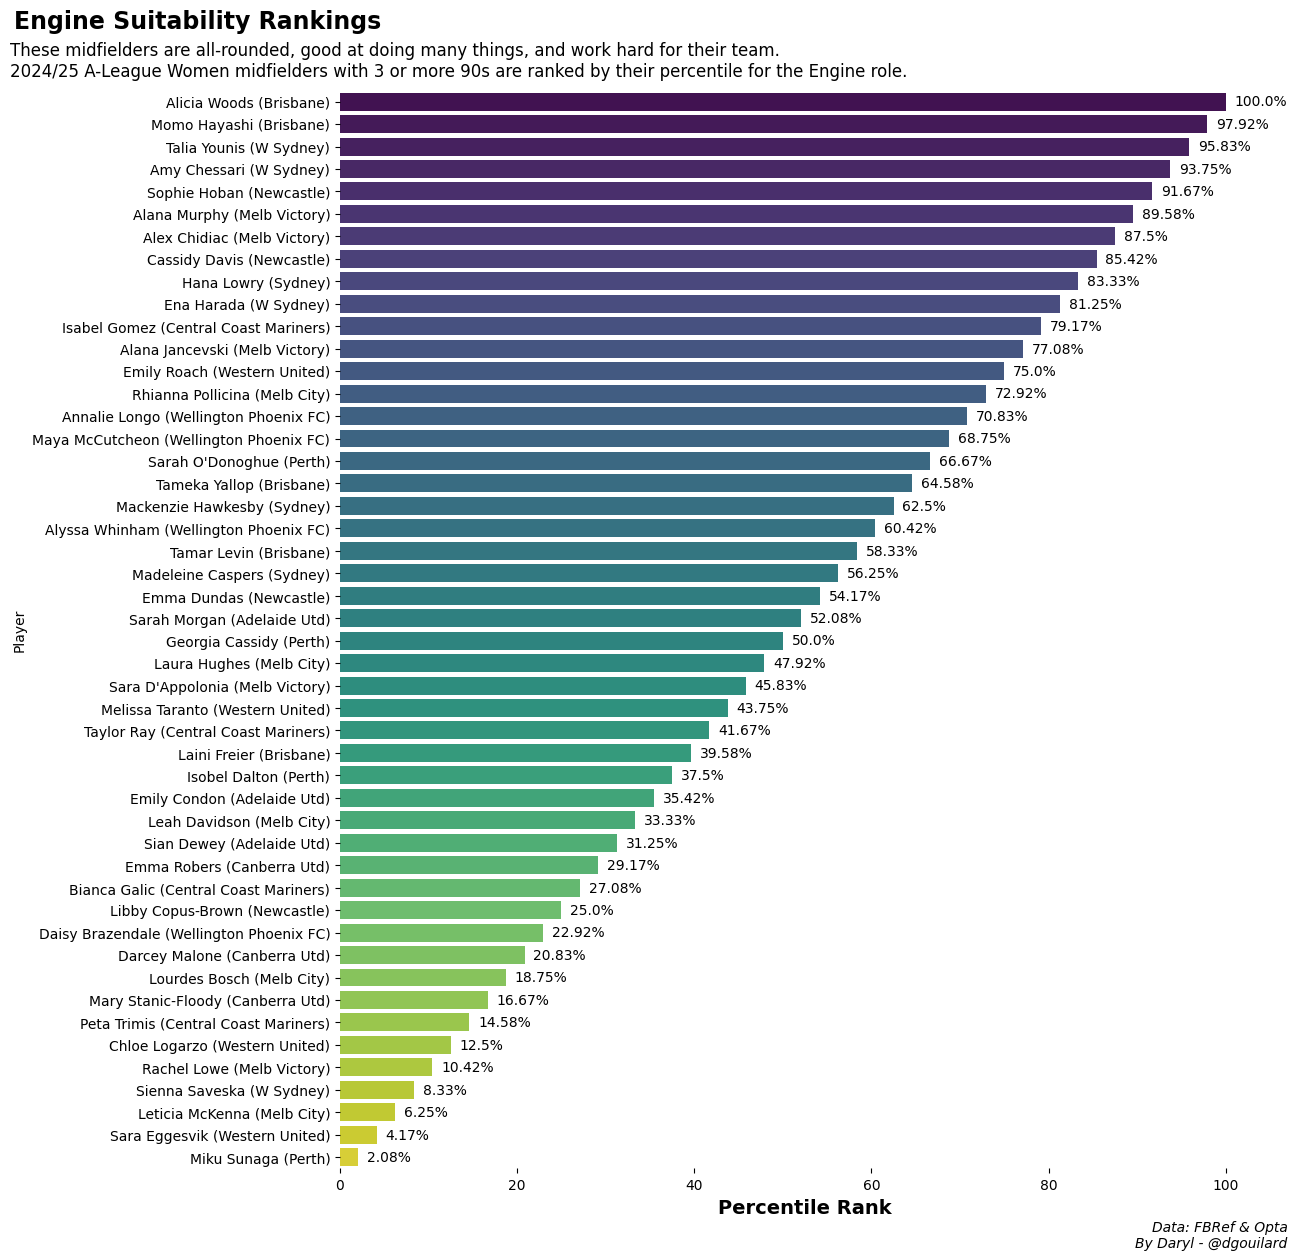

In [14]:
# Sort the roles
role_2 = role_percentiles["Role 2"].sort_values(ascending=False)

# Add team name to the player name
role_2 = role_2.reset_index()
role_2["Player"] = role_2["Player"].apply(
    lambda x: x + " (" + df[df["Player"] == x]["Squad"].values[0] + ")"
)
role_2 = role_2.set_index("Player")
role_2 = role_2["Role 2"]

# Visualize the rankings for Role 2
plt.figure(figsize=(12, 14))
sns.barplot(x=role_2.values, y=role_2.index, palette="viridis", hue=role_2.index)

# Add the percentile values to the bars
for i in range(role_2.shape[0]):
    plt.text(
        x=role_2.values[i] + 1,
        y=i,
        s=f"{round(role_2.values[i], 2)}%",
        va="center",
        ha="left",
    )

# Set the title and labels
plt.title(
    "Engine Suitability Rankings",
    fontsize=17,
    fontweight="bold",
    ha="left",
    y=1.05,
    x=-0.35,
)
plt.suptitle(
    "These midfielders are all-rounded, good at doing many things, and work hard for their team.\n2024/25 A-League Women midfielders with 3 or more 90s are ranked by their percentile for the Engine role.",
    ha="left",
    y=0.915,
    x=-0.15,
)
plt.xlabel("Percentile Rank", fontsize=14, fontweight="bold")
plt.text(
    107,
    51,
    "Data: FBRef & Opta\nBy Daryl - @dgouilard",
    weight="light",
    style="italic",
    fontsize=10,
    ha="right",
)

# Remove the frame
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)

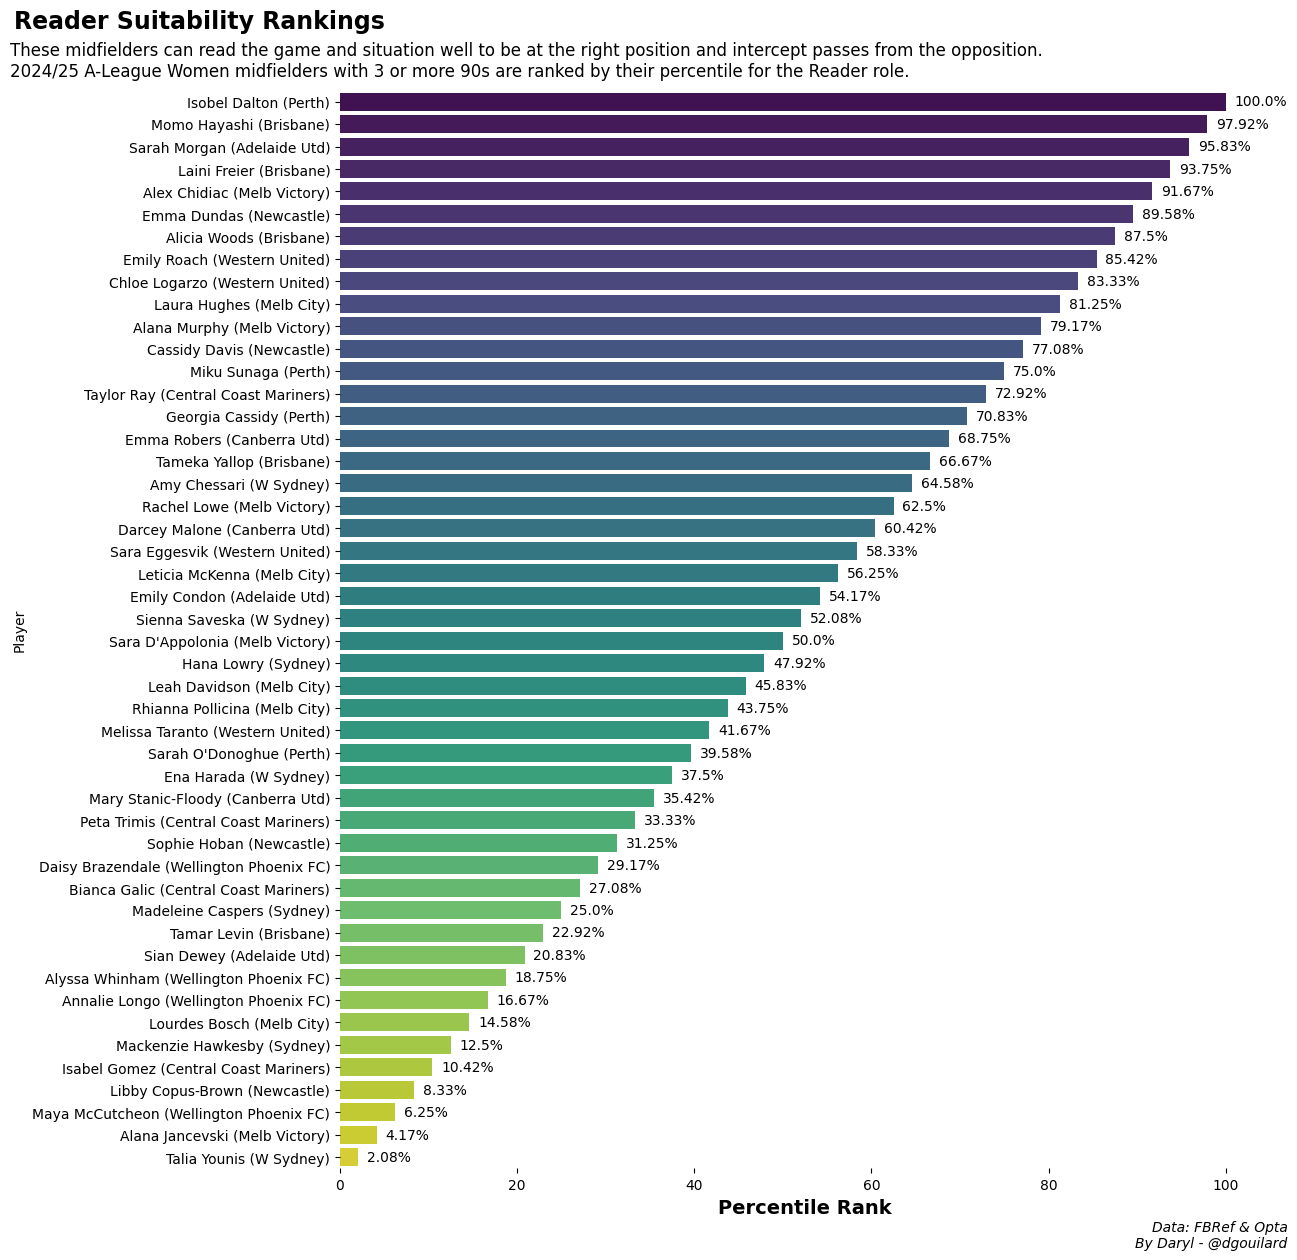

In [15]:
# Sort the roles
role_4 = role_percentiles["Role 4"].sort_values(ascending=False)

# Add team name to the player name
role_4 = role_4.reset_index()
role_4["Player"] = role_4["Player"].apply(
    lambda x: x + " (" + df[df["Player"] == x]["Squad"].values[0] + ")"
)
role_4 = role_4.set_index("Player")
role_4 = role_4["Role 4"]

# Visualize the rankings for Role 4
plt.figure(figsize=(12, 14))
sns.barplot(x=role_4.values, y=role_4.index, palette="viridis", hue=role_4.index)

# Add the percentile values to the bars
for i in range(role_4.shape[0]):
    plt.text(
        x=role_4.values[i] + 1,
        y=i,
        s=f"{round(role_4.values[i], 2)}%",
        va="center",
        ha="left",
    )

# Set the title and labels
plt.title(
    "Reader Suitability Rankings",
    fontsize=17,
    fontweight="bold",
    ha="left",
    y=1.05,
    x=-0.35,
)
plt.suptitle(
    "These midfielders can read the game and situation well to be at the right position and intercept passes from the opposition.\n2024/25 A-League Women midfielders with 3 or more 90s are ranked by their percentile for the Reader role.",
    ha="left",
    y=0.915,
    x=-0.15,
)
plt.xlabel("Percentile Rank", fontsize=14, fontweight="bold")
plt.text(
    107,
    51,
    "Data: FBRef & Opta\nBy Daryl - @dgouilard",
    weight="light",
    style="italic",
    fontsize=10,
    ha="right",
)

# Remove the frame
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)

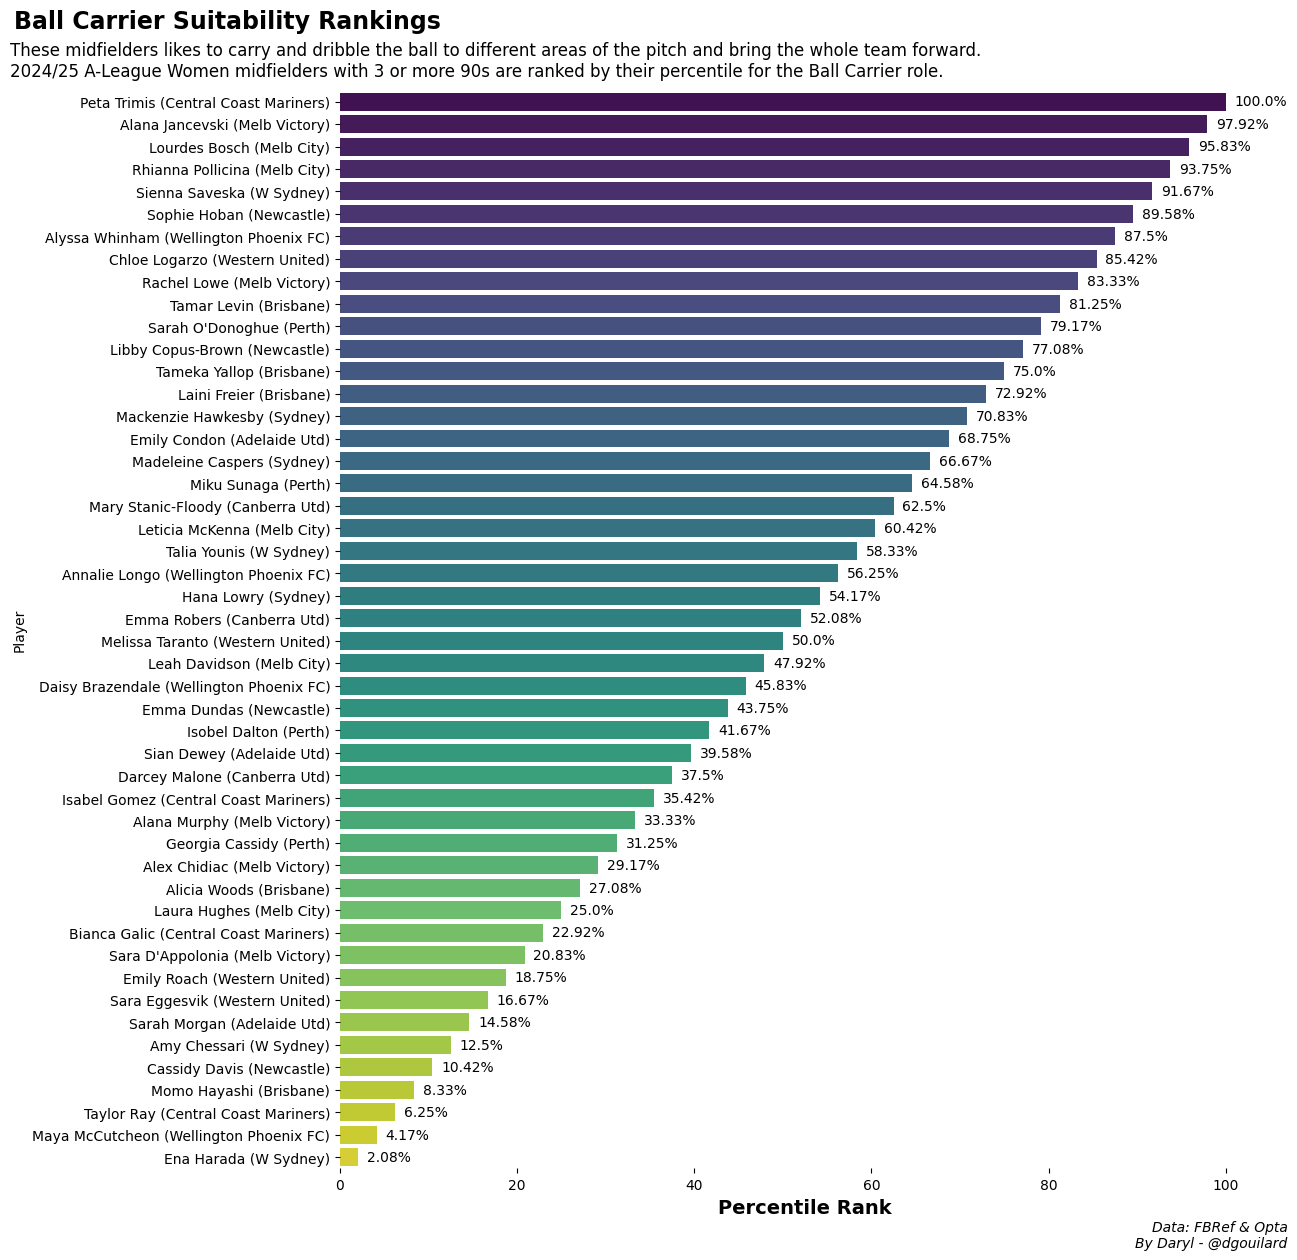

In [16]:
# Sort the roles
role_7 = role_percentiles["Role 7"].sort_values(ascending=False)

# Add team name to the player name
role_7 = role_7.reset_index()
role_7["Player"] = role_7["Player"].apply(
    lambda x: x + " (" + df[df["Player"] == x]["Squad"].values[0] + ")"
)
role_7 = role_7.set_index("Player")
role_7 = role_7["Role 7"]

# Visualize the rankings for Role 7
plt.figure(figsize=(12, 14))
sns.barplot(x=role_7.values, y=role_7.index, palette="viridis", hue=role_7.index)

# Add the percentile values to the bars
for i in range(role_7.shape[0]):
    plt.text(
        x=role_7.values[i] + 1,
        y=i,
        s=f"{round(role_7.values[i], 2)}%",
        va="center",
        ha="left",
    )

# Set the title and labels
plt.title(
    "Ball Carrier Suitability Rankings",
    fontsize=17,
    fontweight="bold",
    ha="left",
    y=1.05,
    x=-0.35,
)
plt.suptitle(
    "These midfielders likes to carry and dribble the ball to different areas of the pitch and bring the whole team forward.\n2024/25 A-League Women midfielders with 3 or more 90s are ranked by their percentile for the Ball Carrier role.",
    ha="left",
    y=0.915,
    x=-0.15,
)
plt.xlabel("Percentile Rank", fontsize=14, fontweight="bold")
plt.text(
    107,
    51,
    "Data: FBRef & Opta\nBy Daryl - @dgouilard",
    weight="light",
    style="italic",
    fontsize=10,
    ha="right",
)

# Remove the frame
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)

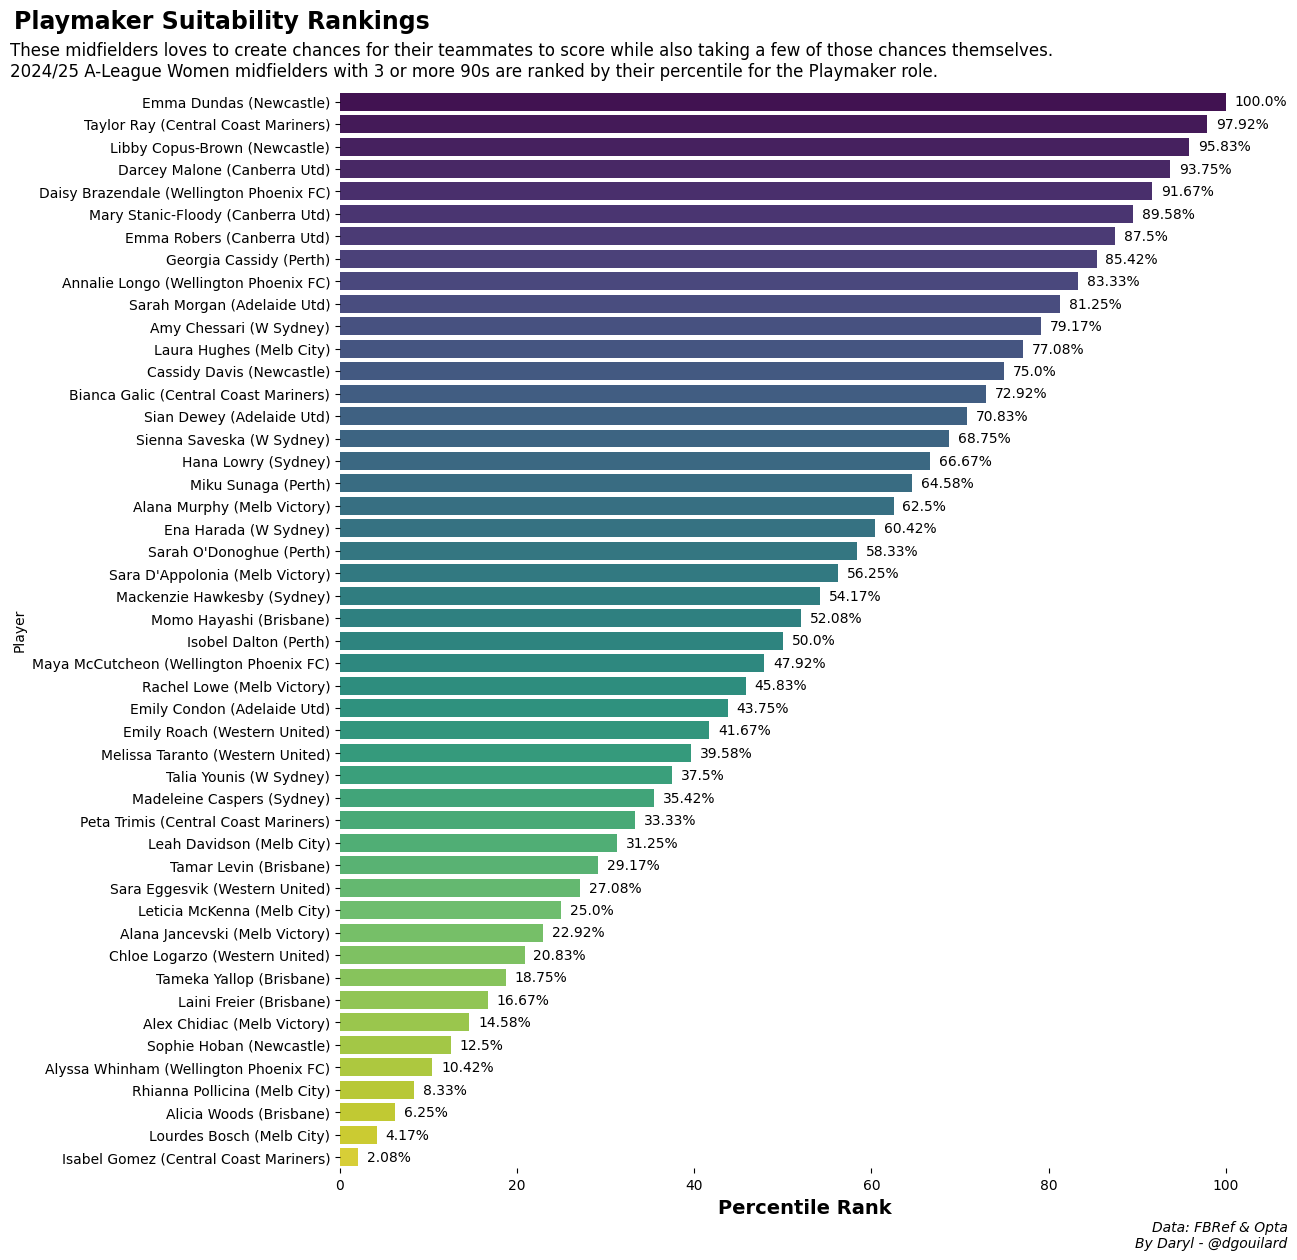

In [17]:
# Sort the roles
role_5 = role_percentiles["Role 5"].sort_values(ascending=False)

# Add team name to the player name
role_5 = role_5.reset_index()
role_5["Player"] = role_5["Player"].apply(
    lambda x: x + " (" + df[df["Player"] == x]["Squad"].values[0] + ")"
)
role_5 = role_5.set_index("Player")
role_5 = role_5["Role 5"]

# Visualize the rankings for Role 5
plt.figure(figsize=(12, 14))
sns.barplot(x=role_5.values, y=role_5.index, palette="viridis", hue=role_5.index)

# Add the percentile values to the bars
for i in range(role_5.shape[0]):
    plt.text(
        x=role_5.values[i] + 1,
        y=i,
        s=f"{round(role_5.values[i], 2)}%",
        va="center",
        ha="left",
    )

# Set the title and labels
plt.title(
    "Playmaker Suitability Rankings",
    fontsize=17,
    fontweight="bold",
    ha="left",
    y=1.05,
    x=-0.35,
)
plt.suptitle(
    "These midfielders loves to create chances for their teammates to score while also taking a few of those chances themselves.\n2024/25 A-League Women midfielders with 3 or more 90s are ranked by their percentile for the Playmaker role.",
    ha="left",
    y=0.915,
    x=-0.15,
)
plt.xlabel("Percentile Rank", fontsize=14, fontweight="bold")
plt.text(
    107,
    51,
    "Data: FBRef & Opta\nBy Daryl - @dgouilard",
    weight="light",
    style="italic",
    fontsize=10,
    ha="right",
)

# Remove the frame
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)

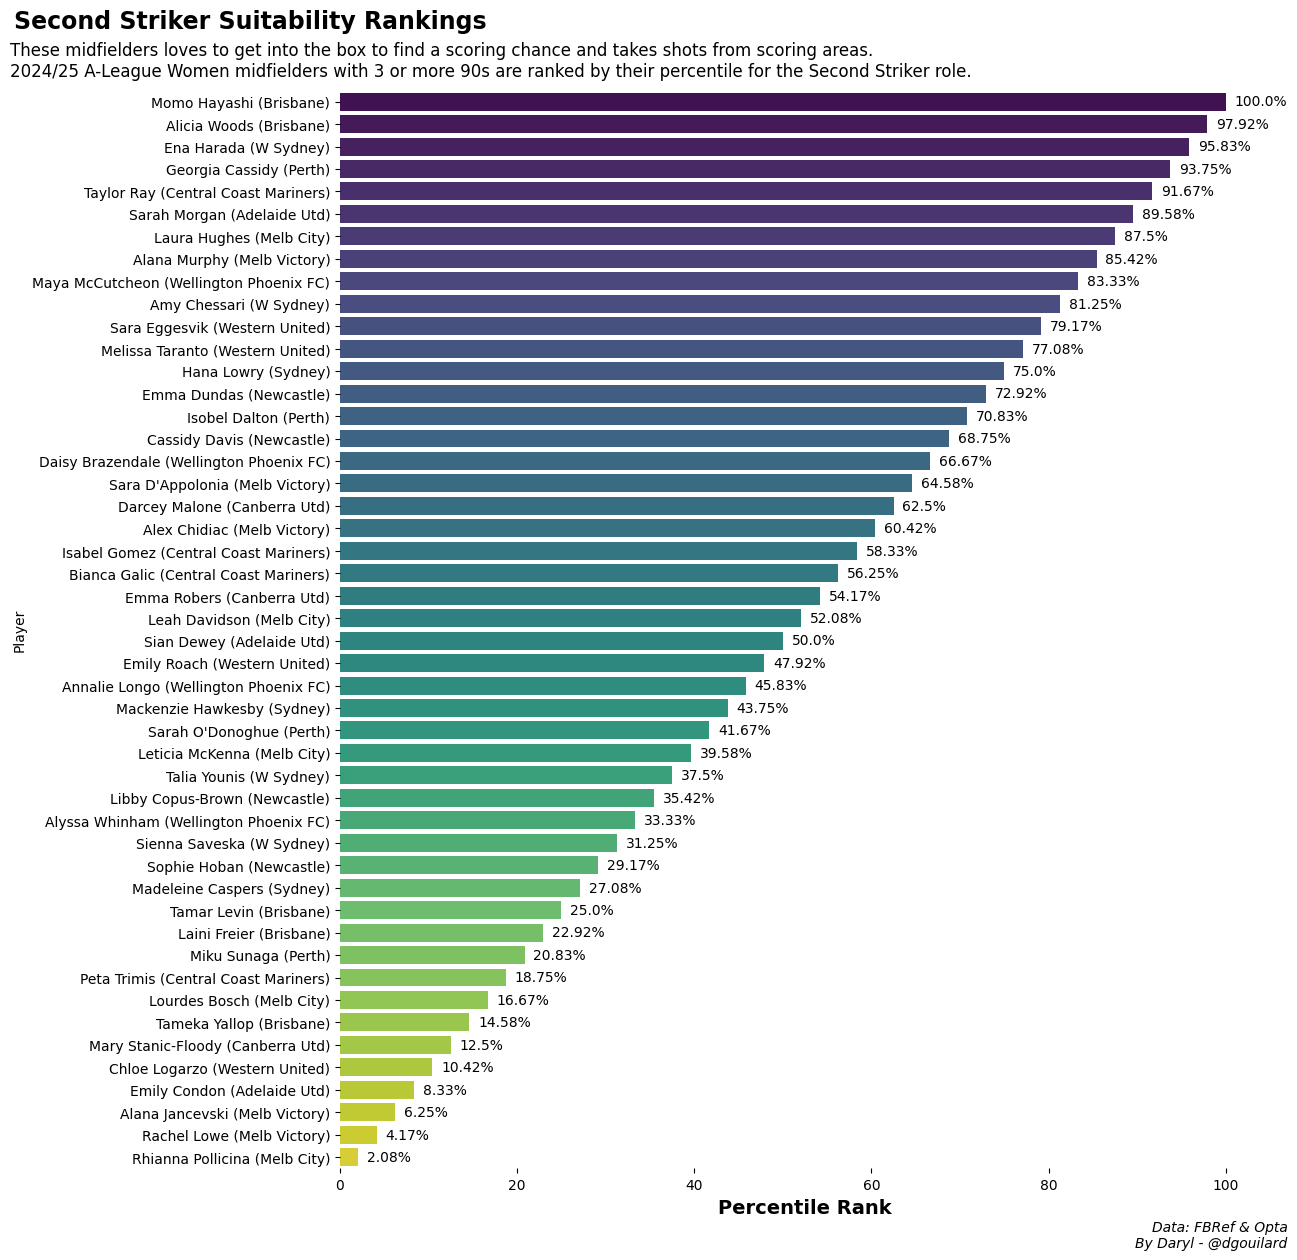

In [18]:
# Sort the roles
role_6 = role_percentiles["Role 6"].sort_values(ascending=False)

# Add team name to the player name
role_6 = role_6.reset_index()
role_6["Player"] = role_6["Player"].apply(
    lambda x: x + " (" + df[df["Player"] == x]["Squad"].values[0] + ")"
)
role_6 = role_6.set_index("Player")
role_6 = role_6["Role 6"]

# Visualize the rankings for Role 6
plt.figure(figsize=(12, 14))
sns.barplot(x=role_6.values, y=role_6.index, palette="viridis", hue=role_6.index)

# Add the percentile values to the bars
for i in range(role_6.shape[0]):
    plt.text(
        x=role_6.values[i] + 1,
        y=i,
        s=f"{round(role_6.values[i], 2)}%",
        va="center",
        ha="left",
    )

# Set the title and labels
plt.title(
    "Second Striker Suitability Rankings",
    fontsize=17,
    fontweight="bold",
    ha="left",
    y=1.05,
    x=-0.35,
)
plt.suptitle(
    "These midfielders loves to get into the box to find a scoring chance and takes shots from scoring areas.\n2024/25 A-League Women midfielders with 3 or more 90s are ranked by their percentile for the Second Striker role.",
    ha="left",
    y=0.915,
    x=-0.15,
)
plt.xlabel("Percentile Rank", fontsize=14, fontweight="bold")
plt.text(
    107,
    51,
    "Data: FBRef & Opta\nBy Daryl - @dgouilard",
    weight="light",
    style="italic",
    fontsize=10,
    ha="right",
)

# Remove the frame
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)

In [19]:
player = "Alicia Woods"
player_index = df[df["Player"] == player].index[0]

# Get the scores for the player
player_scores = pca_scores[player_index]

# Get the percentile ranks for the player
player_roles = role_percentiles.loc[player]

In [20]:
np.round(player_roles.values, 1)

array([ 89.6, 100. ,   8.3,  87.5,   6.2,  97.9,  27.1])

In [21]:
# Import the image
imageLink = "./Images/{player}.png".format(player=player.replace(" ", ""))
playerImage = Image.open(imageLink)

In [22]:
# Import fonts
robotoLight = fm.FontProperties(fname="./Roboto-Light.ttf")
robotoRegular = fm.FontProperties(fname="./Roboto-Regular.ttf")
robotoBold = fm.FontProperties(fname="./Roboto-Bold.ttf")

<Axes: >

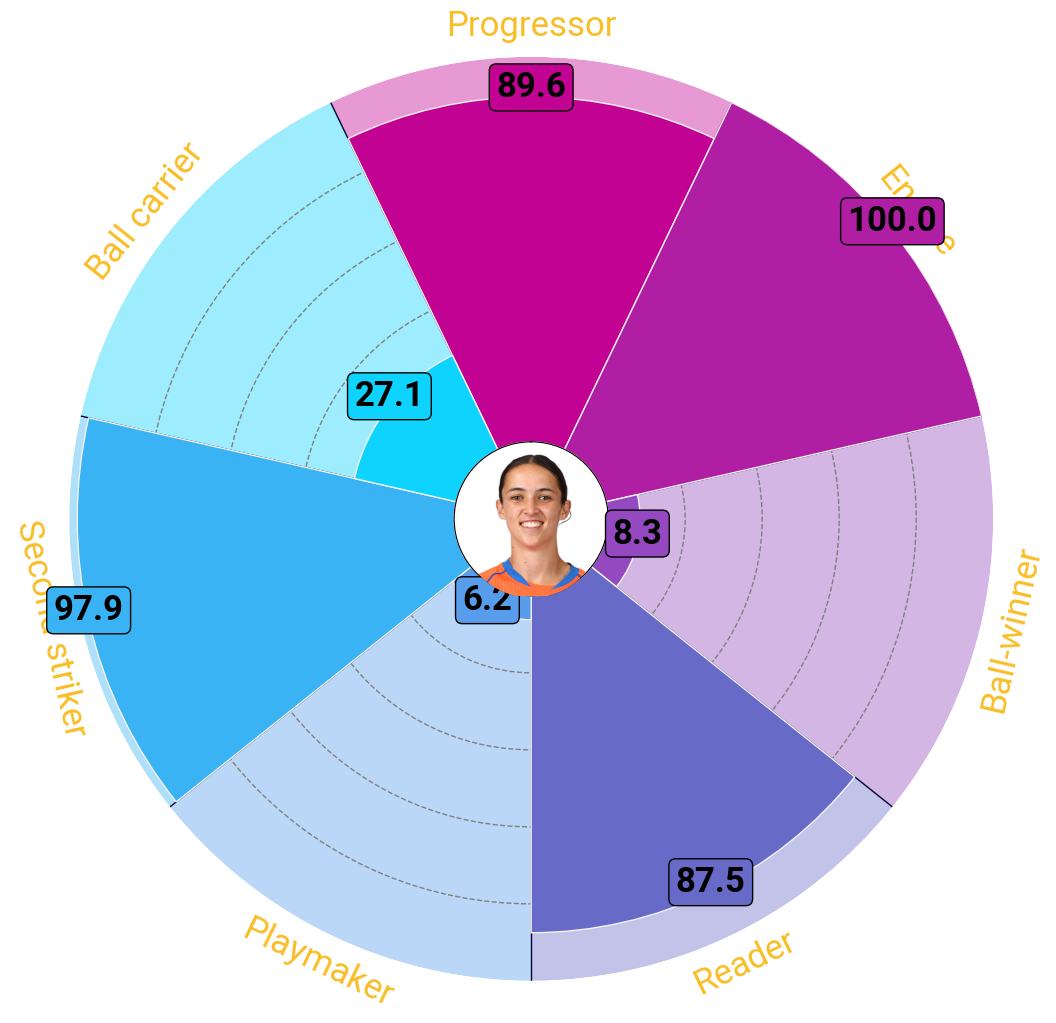

In [26]:
# Create a radar chart
## Instantiate PyPizza class
baker = PyPizza(
    params=[
        "Progressor",
        "Engine",
        "Ball-winner",
        "Reader",
        "Playmaker",
        "Second striker",
        "Ball carrier",
    ],  # list of parameters
    background_color="none",  # background color
    straight_line_color="#030338",  # color for straight lines
    straight_line_lw=1,  # linewidth for straight lines
    last_circle_lw=0,  # linewidth of last circle
    other_circle_ls="--",  # linestyle for other circles
    other_circle_lw=1,  # linewidth for other circles
    inner_circle_size=20,  # size of inner circle
)

## Create a colormap
# colors = ["#c20292", "#0dd3fe"]
# cmap = LinearSegmentedColormap.from_list("TokyoNight", colors, N=len(subjectParams))
slice_colors = (
    ["#c20292"] * 1
    + ["#b01ea4"] * 1
    + ["#9449c0"] * 1
    + ["#686ac8"] * 1
    + ["#579deb"] * 1
    + ["#39b3f3"] * 1
    + ["#0dd3fe"] * 1
)
text_colors = ["#000000"] * len(slice_colors)

# Plot the pizza chart
fig, ax = baker.make_pizza(
    np.round(player_roles.values, 1),
    figsize=(12, 12),
    color_blank_space="same",
    slice_colors=slice_colors,  # color for individual slices
    value_colors=text_colors,  # color for the value-text
    value_bck_colors=slice_colors,  # color for the blank spaces
    blank_alpha=0.4,  # alpha for blank-space colors
    kwargs_slices=dict(
        edgecolor="#F2F2F2", zorder=2, linewidth=1
    ),  # values to be used when plotting slices
    kwargs_params=dict(
        color="#F9BD25", fontsize=25, fontproperties=robotoRegular, va="center"
    ),  # values to be used when adding parameter
    kwargs_values=dict(
        color="#000000",
        fontsize=25,
        fontproperties=robotoBold,
        zorder=3,
        bbox=dict(
            edgecolor="#000000",
            facecolor="cornflowerblue",
            boxstyle="round,pad=0.2",
            lw=1,
        ),
    ),  # values to be used when adding parameter-values
)

# Add an image of Alicia Woods to the plot
add_image(
    playerImage,
    fig,
    left=0.453,
    bottom=0.431,
    width=0.12,
    height=0.12,
)